done with complete graph ODE.  Now simulating
done with complete graph.  Now star --- warning, this may be slow
done with star ODE, now simulating


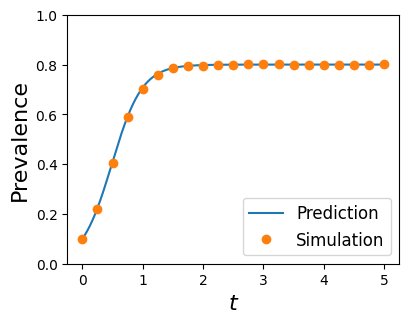

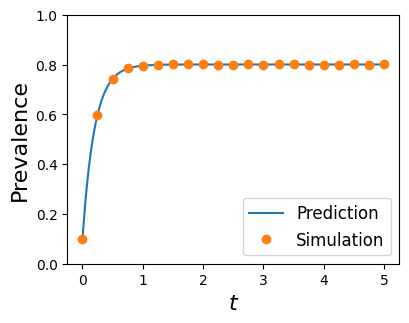

In [1]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy import integrate

import numpy as np

#handling random seeds as described in
#https://networkx.org/documentation/stable/reference/randomness.html
import random
random.seed(5)        # or any integer
np.random.seed(10)

'''
Code to generate figure 2.11.  This is a bit messy because we have to
define the ODE models.  Since python deals with ODEs by taking 1D arrays
we have to set up all the variables into a single long vector.
'''

def star(N):
    G = nx.Graph()
    G.add_node(0)
    for node_id in range(1,N):
        G.add_edge(0,node_id)
    return G




def complete_graph_dX(X, t, tau, gamma, N):
    r'''This system is given in Proposition 2.3, taking Q=S, T=I
    f_{SI}(k) = f_{QT}= k*\tau
    f_{IS}(k) = f_{TQ} = \gamma

    \dot{Y}^0 = \gamma Y^1 - 0\\
    \dot{Y}^1 = 2\gamma Y^2  + 0Y^0 - (\gamma + (N-1)\tau)Y^1
    \dot{Y}^2 = 3\gamma Y^3 + (N-1)\tau Y^1 - (2\gamma+2(N-2))Y^2
    ...
    \dot{Y}^N = (N-1)\tau Y^{N-1} - N\gamma Y^N
    Note that X has length N+1
    '''
    #X[k] is probability of k infections.
    dX = []
    dX.append(gamma*X[1])
    for k in range(1,N):
        dX.append((k+1)*gamma*X[k+1]+ (N-k+1)*(k-1)*tau*X[k-1]
                    - ((N-k)*k*tau + k*gamma)*X[k])
    dX.append((N-1)*tau*X[N-1] - N*gamma*X[N])

    return np.array(dX)

def complete_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount):
    times = np.linspace(tmin, tmax, tcount)
    X0 = np.zeros(N+1)  #length N+1 of just 0 entries
    X0[I0]=1. #start with 100 infected.
    X = integrate.odeint(complete_graph_dX, X0, times, args = (tau, gamma, N))
    #X[t] is array whose kth entry is p(k infected| time=t).
    I = np.array([sum(k*Pkt[k] for k in range(len(Pkt))) for Pkt in X])
    S = N-I
    return times, S, I


def star_graph_dX(X, t, tau, gamma, N):
    '''this system is given in Proposition 2.4, taking Q=S, T=I
    so f_{SI}(k) = f_{QT}(k) = k*tau
    f_{IS}(k) = f_{TQ}(k) = gamma
    X has length 2*(N-1)+2 = 2N'''

    #    [[central node infected] + [central node susceptible]]
    #X = [Y_1^1, Y_1^2, ..., Y_1^{N}, Y_2^0, Y_2^1, ..., Y_2^{N-1}]

    #Note that in proposition Y^0 is same as Y_2^0
    #and Y^N is same as Y_1^N

    #Y1[k]: central node infected, & k-1 peripheral nodes infected
    Y1vec = [0]+list(X[0:N])      #for Y_1^k, use Y1vec[k]
    #pad with 0 to make easier calculations Y_1^0=0
    #the probability of -1 nodes infected is 0

    #Y2[k]: central node susceptible & k peripheral nodes infected
    Y2vec = list(X[N:])+[0]   #for Y_2^k use Y2vec[k]
    #padded with 0 to make easier calculations. Y_2^N=0
    #the probability of N (of N-1) peripheral nodes infected is 0
    dY1vec = []
    dY2vec = []
    for k in range(1, N):
        #k-1 peripheral nodes infected, central infected
        dY1vec.append((N-k+1)*tau*Y1vec[k-1] + (k-1)*tau*Y2vec[k-1]
                    +k*gamma*Y1vec[k+1]
                    - ((N-k)*tau + (k-1)*gamma+gamma)*Y1vec[k])
    #now the Y^N equation
    dY1vec.append(tau*Y1vec[N-1] + (N-1)*tau*Y2vec[N-1] - N*gamma*Y1vec[N])

    #now the Y^0 equation
    dY2vec.append(gamma*(N-1)*Y1vec[1] + gamma*Y2vec[1]-0)

    for k in range(1,N):
        #k peripheral nodes infected, central susceptible
        dY2vec.append(0 + gamma*Y1vec[k+1] + gamma*(k+1)*Y2vec[k+1]
                    - (k*tau + 0 + k*gamma)*Y2vec[k])

    return np.array(dY1vec + dY2vec)

def star_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount):
    times = np.linspace(tmin, tmax, tcount)
    #    [[central node infected] + [central node susceptible]]
    #X = [Y_1^1, Y_1^2, ..., Y_1^{N}, Y_2^0, Y_2^1, ..., Y_2^{N-1}]
    X0 = np.zeros(2*N)  #length 2*N of just 0 entries
    X0[I0]=I0*1./N #central infected, + I0-1 periph infected prob
    X0[N+I0] = 1-I0*1./N #central suscept + I0 periph infected
    X = EoN.analytic._my_odeint_(star_graph_dX, X0, times, args = (tau, gamma, N))
    #X looks like [[central susceptible,k periph] [ central inf, k-1 periph]] x T

    central_inf = X[:,:N]
    central_susc = X[:,N:]

    I = np.array([ sum(k*central_susc[t][k] for k in range(N))
            + sum((k+1)*central_inf[t][k] for k in range(N))
            for t in range(len(X))])
    S = N-I
    return times, S, I




N=1000
I0=int(0.1*N)
iterations = 100 #number of simulations to compare
gamma = 1
tmin=0
tmax=5
tcount = 1001
report_times = np.linspace(tmin, tmax, 21) #for simulations



plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)

plt.figure(0)
tau = 0.005
G = nx.complete_graph(N)
t, S, I = complete_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount)
plt.plot(t, I/N, label = 'Prediction')

#now check with simulation
obs_I = 0*report_times
print("done with complete graph ODE.  Now simulating")
for counter in range(iterations):
    IC = random.sample(range(N),I0)
    t, S, I = EoN.fast_SIS(G, tau, gamma, initial_infecteds = IC, tmax = tmax)
    obs_I += EoN.subsample(report_times, t, I)
plt.plot(report_times, obs_I*1./(iterations*N), 'o', label='Simulation')
plt.axis(ymin=0, ymax=1)
plt.xlabel('$t$', fontsize=16)
plt.ylabel('Prevalence', fontsize=16)
plt.legend(fontsize=12)
plt.savefig('fig2p12a.png', bbox_inches='tight', dpi=900)

print("done with complete graph.  Now star --- warning, this may be slow")



plt.figure(1)
#for star, if 100 nodes randomly start infected, 1/10 cases have
#central node infected and 99 peripheral.  9/10 have 100 peripheral.

tau = 4.
G = star(N)

t, S, I = star_graph_lumped(N, tau, gamma, I0, tmin, tmax, tcount)
plt.plot(t, I/N, label = 'Prediction')
print("done with star ODE, now simulating")

obs_I = 0*report_times
for counter in range(iterations):
    IC = random.sample(range(N),I0)
    t, S, I = EoN.fast_SIS(G, tau, gamma, initial_infecteds = IC, tmax = tmax)
    obs_I += EoN.subsample(report_times, t, I)
plt.plot(report_times, obs_I*1./(iterations*N), 'o', label='Simulation')
plt.axis(ymin=0, ymax=1)
plt.xlabel('$t$', fontsize=16)
plt.ylabel('Prevalence', fontsize=16)
plt.legend(fontsize=12)
plt.savefig('fig2p12b.png', dpi=900)

In [ ]:
EoN.analytic._my_odeint_

<function EoN.analytic._my_odeint_(dfunc, V0, times, args=())>